In [ ]:
#%pip install scanpy #if libraries not found

In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd

In [2]:
adata = ad.read_h5ad("/dcs04/lieber/lcolladotor/spatialDLPFC_LIBD4035/spatialDLPFC/raw-data/psychENCODE/version5/SZBDMulti-Seq_annotated.h5ad")

In [4]:
adata.X[1:4,1:13].todense()

matrix([[0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
         0.      , 0.      , 0.      , 0.      , 0.      , 0.      ],
        [0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
         0.      , 0.      , 0.      , 0.      , 0.      , 0.      ],
        [0.      , 0.      , 0.      , 2.901414, 0.      , 0.      ,
         0.      , 0.      , 0.      , 0.      , 0.      , 0.      ]],
       dtype=float32)

In [5]:
adata.raw.X[1:4,1:13].todense()

matrix([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 2., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [3]:
adata.layers["counts"] = adata.raw.X.copy()
adata = adata[-adata.obs.individualID.str.contains('SZ')]
adata #312828 x 34291

View of AnnData object with n_obs × n_vars = 312828 × 34291
    obs: 'n_genes', 'n_counts', 'Channel', 'demux_type', 'assignment', 'anno', 'subclass', 'azimuth', 'individualID'
    var: 'featureid', 'n_cells', 'percent_cells'
    uns: 'PCs', '_attr2type', 'genome', 'leiden_resolution', 'modality', 'ncells', 'norm_count', 'pca', 'pca_features', 'stdzn_max_value', 'stdzn_mean', 'stdzn_std', 'uns_dict', 'var_dict'
    obsm: 'X_pca', 'X_pca_harmony', 'X_pca_regressed', 'X_pca_regressed_harmony', 'X_umap', 'pca_harmony_knn_distances', 'pca_harmony_knn_indices', 'pca_regressed_harmony_knn_distances', 'pca_regressed_harmony_knn_indices'
    varm: 'de_res', 'means', 'partial_sum'
    layers: 'counts'
    obsp: 'W_pca_harmony', 'W_pca_regressed_harmony'

### Load in metadata and merge with adata

In [4]:
mdata = pd.read_csv('https://brainscope.gersteinlab.org/data/sample_metadata/PEC2_sample_metadata.txt', delimiter='\t')
mdata = mdata[mdata.Cohort=='SZBDMulti-Seq']
mdata = mdata[mdata.Disorder.isin(['control','Bipolar Disorder'])]

#rename mdata column for easier merge with adata obs
mdata = mdata.rename(columns={"Individual_ID":"individualID"})

In [5]:
#merging will automatically switch index to integer so first store orig/desired index as column then merge and then reset index so compatible with adata
adata.obs = adata.obs.reset_index().merge(mdata[mdata.columns[0:5]], on="individualID", how="left").set_index('barcodekey')

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

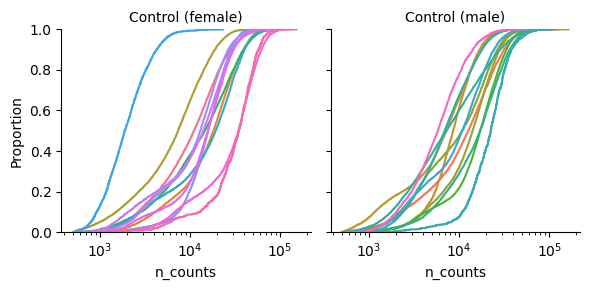

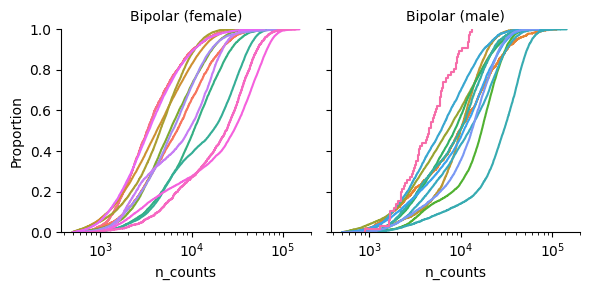

In [7]:
g = sns.FacetGrid(adata.obs[adata.obs.Disorder=="control"], col="Biological_Sex", hue="individualID")
g.map(sns.ecdfplot, "n_counts", log_scale= True)
g.set_titles('Control ({col_name})')

g = sns.FacetGrid(adata.obs[adata.obs.Disorder=="Bipolar Disorder"], col="Biological_Sex", hue="individualID")
g.map(sns.ecdfplot, "n_counts", log_scale= True)
g.set_titles('Bipolar ({col_name})')

In [8]:
adata.obs.groupby('individualID').mean(numeric_only = True).n_counts.nsmallest(5)
#CON17

individualID
CON17    2366.252883
BD1      4878.740544
BD21     5028.192066
BD24     5259.242424
BD6      5455.790055
Name: n_counts, dtype: float64

In [9]:
mdata[mdata['individualID']=="CON17"]

,Cohort,individualID,Biological_Sex,Age_death,Disorder,1000G_ancestry,Genotype_data,snATAC-Seq,PMI,pH,RIN,Notes
269,SZBDMulti-Seq,CON17,female,89+,control,EUR,Array,None,15.4,NaN,NaN,NaN


In [10]:
mdata[mdata['Age_death']=="89+"]

,Cohort,individualID,Biological_Sex,Age_death,Disorder,1000G_ancestry,Genotype_data,snATAC-Seq,PMI,pH,RIN,Notes
239,SZBDMulti-Seq,BD11,female,89+,Bipolar Disorder,EUR,Array,None,13.0,NaN,NaN,NaN
269,SZBDMulti-Seq,CON17,female,89+,control,EUR,Array,None,15.4,NaN,NaN,NaN


In [11]:
mdata = mdata[mdata["Age_death"]!="89+"]
mdata["Age_death"] = pd.to_numeric(mdata.Age_death)

<Axes: xlabel='Disorder', ylabel='Age_death'>

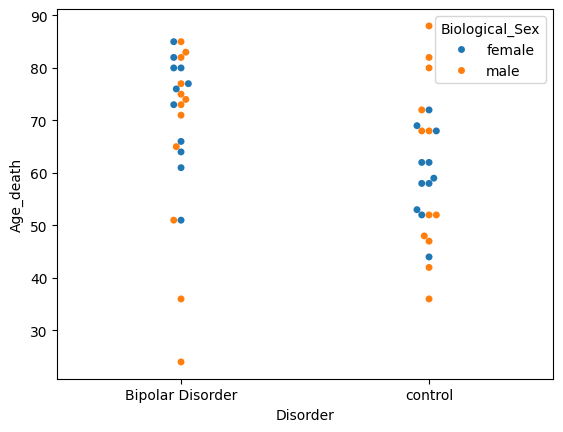

In [12]:
sns.swarmplot(mdata, x="Disorder", y="Age_death", hue="Biological_Sex")

In [13]:
adata = adata[adata.obs.Age_death!="89+"]

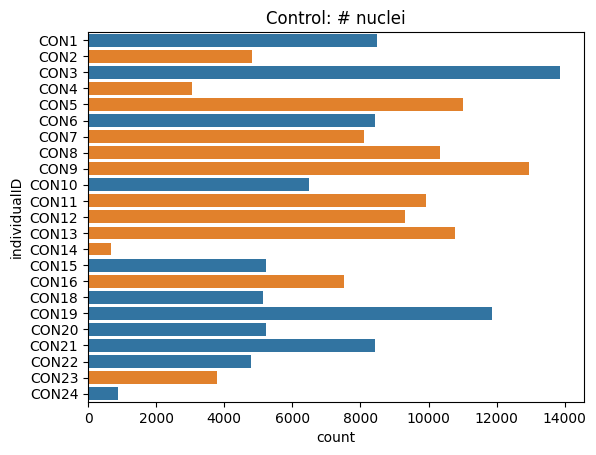

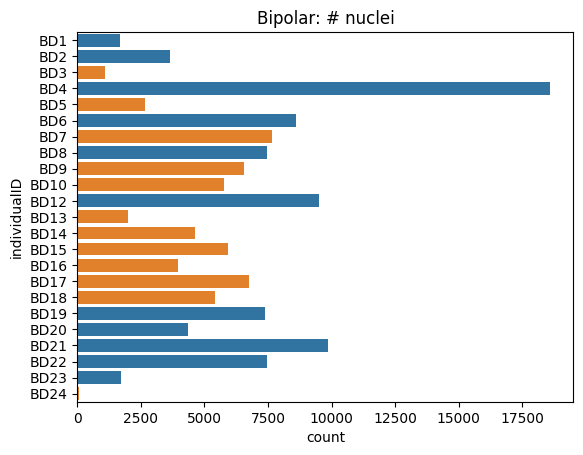

In [14]:
p1 = sns.countplot(adata.obs[adata.obs.Disorder=="control"], y="individualID", hue="Biological_Sex", 
              orientation="horizontal", legend=False)
plt.title("Control: # nuclei")
plt.show()

p2 = sns.countplot(adata.obs[adata.obs.Disorder=="Bipolar Disorder"], y="individualID", hue="Biological_Sex", 
              orientation="horizontal", legend=False)
plt.title("Bipolar: # nuclei")
plt.show()

In [15]:
adata = adata[~adata.obs.individualID.isin(["CON14","CON24","BPD24","BD3"])]
adata # 301136 x 34291

View of AnnData object with n_obs × n_vars = 301136 × 34291
    obs: 'n_genes', 'n_counts', 'Channel', 'demux_type', 'assignment', 'anno', 'subclass', 'azimuth', 'individualID', 'Cohort', 'Biological_Sex', 'Age_death', 'Disorder'
    var: 'featureid', 'n_cells', 'percent_cells'
    uns: 'PCs', '_attr2type', 'genome', 'leiden_resolution', 'modality', 'ncells', 'norm_count', 'pca', 'pca_features', 'stdzn_max_value', 'stdzn_mean', 'stdzn_std', 'uns_dict', 'var_dict'
    obsm: 'X_pca', 'X_pca_harmony', 'X_pca_regressed', 'X_pca_regressed_harmony', 'X_umap', 'pca_harmony_knn_distances', 'pca_harmony_knn_indices', 'pca_regressed_harmony_knn_distances', 'pca_regressed_harmony_knn_indices'
    varm: 'de_res', 'means', 'partial_sum'
    layers: 'counts'
    obsp: 'W_pca_harmony', 'W_pca_regressed_harmony'

<Axes: xlabel='n_cells', ylabel='Count'>

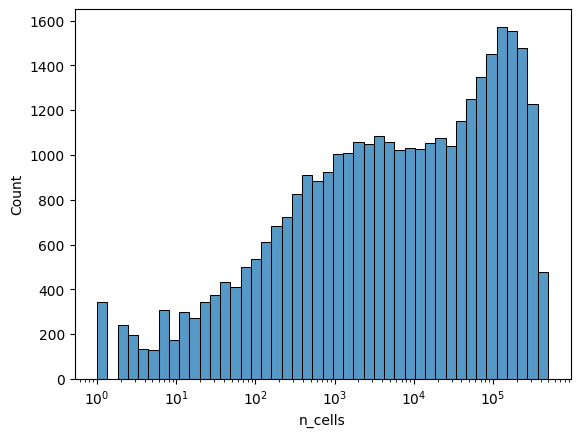

In [16]:
sns.histplot(adata.var, x="n_cells", log_scale= True)

In [17]:
adata = adata[:,adata.var.n_cells>100]
adata #301136 x 29887

View of AnnData object with n_obs × n_vars = 301136 × 29887
    obs: 'n_genes', 'n_counts', 'Channel', 'demux_type', 'assignment', 'anno', 'subclass', 'azimuth', 'individualID', 'Cohort', 'Biological_Sex', 'Age_death', 'Disorder'
    var: 'featureid', 'n_cells', 'percent_cells'
    uns: 'PCs', '_attr2type', 'genome', 'leiden_resolution', 'modality', 'ncells', 'norm_count', 'pca', 'pca_features', 'stdzn_max_value', 'stdzn_mean', 'stdzn_std', 'uns_dict', 'var_dict'
    obsm: 'X_pca', 'X_pca_harmony', 'X_pca_regressed', 'X_pca_regressed_harmony', 'X_umap', 'pca_harmony_knn_distances', 'pca_harmony_knn_indices', 'pca_regressed_harmony_knn_distances', 'pca_regressed_harmony_knn_indices'
    varm: 'de_res', 'means', 'partial_sum'
    layers: 'counts'
    obsp: 'W_pca_harmony', 'W_pca_regressed_harmony'

In [18]:
adata.layers["counts"].shape

(301136, 29887)

In [21]:
adata.write_h5ad("/dcs04/lieber/marmaypag/spatialDLPFC_mdd_bpd_LIBD4100/spatialDLPFC_mdd_bpd/processed-data/05_clustering/Seurat/adata_SZBDMulti-Seq_filtered.h5")

In [23]:
adata.layers['counts'].shape#raw.X.shape #didn't get filtered

(301136, 29887)

In [90]:
counts = adata.raw.X.copy()
counts = counts[:,adata.raw.var['featureid'].isin(adata.var.featureid)]
counts.shape

(301136, 29887)

In [24]:
adata.obs.to_csv("/dcs04/lieber/marmaypag/spatialDLPFC_mdd_bpd_LIBD4100/spatialDLPFC_mdd_bpd/processed-data/05_clustering/Seurat/obs_SZBDMulti-Seq_filtered.csv")

In [25]:
adata.var.to_csv("/dcs04/lieber/marmaypag/spatialDLPFC_mdd_bpd_LIBD4100/spatialDLPFC_mdd_bpd/processed-data/05_clustering/Seurat/var_SZBDMulti-Seq_filtered.csv")

In [29]:
import numpy
numpy.savetxt("/dcs04/lieber/marmaypag/spatialDLPFC_mdd_bpd_LIBD4100/spatialDLPFC_mdd_bpd/processed-data/05_clustering/Seurat/raw-counts_SZBDMulti-Seq_filtered.csv", 
              adata.layers['counts'].todense(), delimiter=",")

In [30]:
print("done")

done
